# Initial model inspection


In [1]:
import cobra
import json
import memote

model = cobra.io.read_sbml_model("p_simiae_model_glucose_min.xml")
model_segre = cobra.io.read_sbml_model("Psimiae_withATPM.xml")

#load necessary modules and model

'' is not a valid SBML 'SId'.


In [2]:
model

#test model gene count and reaction number

Name,
Memory address,7e5baa585d30
Number of metabolites,1393
Number of reactions,1601
Number of genes,1444
Number of groups,0
Objective expression,1.0*bio1_biomass - 1.0*bio1_biomass_reverse_6e711
Compartments,"c0, e0"


In [3]:
model_segre

#compare with the only other P simiae model I found in the literature

Name,psimiae_utrecht_RASTtk_genome
Memory address,7e5baa022d50
Number of metabolites,1386
Number of reactions,1650
Number of genes,1347
Number of groups,0
Objective expression,1.0*bio1_biomass - 1.0*bio1_biomass_reverse_6e711
Compartments,"c0, e0"


In [4]:
model.remove_reactions(model.reactions.get_by_id("rxn07295_c0"))

#this manual curation is necessary to ensure model stoichiometric consistency, as the reaction above is a poorly defined, non-gene-associated duplicate of "rxn23045_c0", which leads to stoichiometric inconsistency. This was found based on a search conducted with Claude AI, Sonnet 5.5

/home/gestrella/anaconda3/lib/python3.13/site-packages/cobra/core/model.py:779: UserWarning: need to pass in a list
  warn("need to pass in a list")


# Model verification

MEMOTE tests and baseline growth checks.


In [5]:
from memote.suite.api import test_model, snapshot_report

code, results = test_model(model, results=True)

html_content = snapshot_report(results)
with open("memote_final_report.html", "w", encoding="utf-8") as f:
    f.write(html_content)

#run test suite and generate + save the HTML MEMOTE report on my own model


============================= test session starts ==============================
platform linux -- Python 3.13.9, pytest-8.4.2, pluggy-1.5.0
rootdir: /home/gestrella
plugins: typeguard-4.6.0, anyio-4.10.0
collected 146 items / 1 skipped

../../../../../../../anaconda3/lib/python3.13/site-packages/memote/suite/tests/test_annotation.py . [  0%]
..FF.FFFFFFFFFFFFFFFFFFFFFFFFFFFFF..FFFFF.F....FFFF.FFFFFFFFFF..         [ 44%]
../../../../../../../anaconda3/lib/python3.13/site-packages/memote/suite/tests/test_basic.py F [ 45%]
.....F............F.FF                                                   [ 60%]
../../../../../../../anaconda3/lib/python3.13/site-packages/memote/suite/tests/test_biomass.py . [ 60%]
F..FF...F                                                                [ 67%]
../../../../../../../anaconda3/lib/python3.13/site-packages/memote/suite/tests/test_consistency.py . [ 67%]
..FFFFF......ss.F.FFFFFF.FFF                                             [ 86%]
../../../../../../../

In [6]:
from memote.suite.api import test_model, snapshot_report

code, results = test_model(model_segre, results=True)

html_content = snapshot_report(results)
with open("memote_final_report_segre.html", "w", encoding="utf-8") as f:
    f.write(html_content)

#run test suite and generate + save the HTML MEMOTE report on the literature model

============================= test session starts ==============================
platform linux -- Python 3.13.9, pytest-8.4.2, pluggy-1.5.0
rootdir: /home/gestrella
plugins: typeguard-4.6.0, anyio-4.10.0
collected 146 items / 1 skipped

../../../../../../../anaconda3/lib/python3.13/site-packages/memote/suite/tests/test_annotation.py F [  0%]
F.FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF..FFFFF.F....FFFF.FFFFFFFFFF..         [ 44%]
../../../../../../../anaconda3/lib/python3.13/site-packages/memote/suite/tests/test_basic.py . [ 45%]
.....F........F..FF.FF                                                   [ 60%]
../../../../../../../anaconda3/lib/python3.13/site-packages/memote/suite/tests/test_biomass.py . [ 60%]
F..FF....                                                                [ 67%]
../../../../../../../anaconda3/lib/python3.13/site-packages/memote/suite/tests/test_consistency.py . [ 67%]
..FFFFFFF..FFssFFFFFFFFF.FFF                                             [ 86%]
../../../../../../../

Results from Memote report appear to be close to  Pseudomonas putida model in literature https://bigg.bio/models/iJN1463/ 

Only other P. simiae model present in the literature/pre-print (model_segre) and it was found to have similar MEMOTE results, albeit with slightly less realistic growth rate growth rate predictions as seen below

In [7]:
solution = model.optimize()
print("Predicted growth rate (per hour):", solution.objective_value)

#test growth prediction

Predicted growth rate (per hour): 74.61761303317596


In [8]:
solution = model_segre.optimize()
print("Predicted growth rate (per hour):", solution.objective_value)

#test growth prediction

Predicted growth rate (per hour): 170.45173419559154


Growth rate prediction found to be excessive under the unbounded medium (not surprisingly). From now on, only work on the present report's model is looked at. Medium will be subsequently bound

In [9]:
ATPM = model.reactions.get_by_id("rxn00062_c0")
ATPM

#investigate ATP maintanance rxn

Reaction identifier,rxn00062_c0
Name,ATP hydrolysis
Memory address,0x7e5ba92ec520
Stoichiometry,cpd00001_c0 + cpd00002_c0 --> cpd00008_c0 + cpd00009_c0 + cpd00067_c0 H2O [c0] + ATP [c0] --> ADP [c0] + Phosphate [c0] + H+ [c0]
GPR,
Lower bound,0.0
Upper bound,1000.0


ATPM found not to be bound

In [10]:
ATPM.lower_bound = 0.92
ATPM.upper_bound = 0.92

#set lower and upper bounds to the already standardized 0.92 (same as in https://bigg.bio/models/iJN1463/reactions/ATPM)

This should make sense to ensure at least a literature-consistent Pseudomonas simiae simulation, as it is also a Pseudomonas being simulated.

# Defined minimal medium

All exchanges are closed, then only glucose, O₂, and essential inorganics (including Cl⁻) are reopened. ATPM is fixed at 0.92 mmol gDW⁻¹ h⁻¹. `apply_minimal_medium()` is the single source of truth for later sections.


In [11]:
from cobra import Reaction
import warnings

PSIMIAE_INORGANICS = {
    "EX_cpd00007_e0": -20.0,   # O2          (aerobic default; set 0 for anaerobic)
    "EX_cpd00001_e0": -1000.0, # H2O
    "EX_cpd00067_e0": -1000.0, # H+
    "EX_cpd00009_e0": -1000.0, # Phosphate
    "EX_cpd00013_e0": -1000.0, # NH4+        (sole N source)
    "EX_cpd00048_e0": -1000.0, # Sulfate     (sole S source)
    "EX_cpd00254_e0": -1000.0, # Mg2+
    "EX_cpd00063_e0": -1000.0, # Ca2+
    "EX_cpd00030_e0": -1000.0, # Mn2+
    "EX_cpd00034_e0": -1000.0, # Zn2+
    "EX_cpd10515_e0": -1000.0, # Fe2+
    "EX_cpd10516_e0": -1000.0, # Fe3+
    "EX_cpd00149_e0": -1000.0, # Co2+
    "EX_cpd00058_e0": -1000.0, # Cu2+
    "EX_cpd00971_e0": -1000.0, # Na+
    "EX_cpd00205_e0": -1000.0, # K+
    "EX_cpd00099_e0": -1000.0, # Cl-        (required by biomass; Grok AI 4.6 diagnosis hit)
}

# Sole carbon source under standard aerobic growth
PSIMIAE_CARBON = {
    "EX_cpd00027_e0": -10.0,   # D-Glucose   (max uptake 10 mmol/gDW/h)
}

# Optional electron acceptors (kept closed unless an experiment opens them)
PSIMIAE_NOX = {
    "EX_cpd00209_e0": 0.0,     # Nitrate
    "EX_cpd00075_e0": 0.0,     # Nitrite
}

ATPM_ID = "rxn00062_c0"
ATPM_LB = 0.92                 # mmol/gDW/h  (iJN1463 / literature Pseudomonas)
BIOMASS_ID = "bio1_biomass"


def apply_minimal_medium(
    model,
    glucose_lb=-10.0,
    o2_lb=-20.0,
    atpm_lb=ATPM_LB,
    allow_nitrate=False,
    allow_nitrite=False,
    nitrate_lb=-20.0,
    nitrite_lb=-20.0,
    close_storage=True,
    set_objective_biomass=True,
    verbose=True,
):
    """
    Lock the model to a defined *P. simiae* minimal medium.

    Steps
    -----
    1. Set EVERY exchange lower_bound = 0  (block all imports).
    2. Open the inorganic base + glucose + O2 at the requested rates.
    3. Optionally open nitrate / nitrite for anaerobic respiration tests.
    4. Fix ATPM lower bound; close free PHA storage demand.
    5. Set biomass as objective (optional).

    Returns
    -------
    list of exchange reaction IDs that remain open for uptake (LB < 0).
    """
    # 1. Close all exchanges — no exceptions
    for rxn in model.exchanges:
        rxn.lower_bound = 0.0
        rxn.upper_bound = 1000.0  # secretion still allowed

    # 2. Inorganic base
    opened = []
    for rid, lb in PSIMIAE_INORGANICS.items():
        if rid not in model.reactions:
            if verbose:
                warnings.warn(f"Inorganic exchange missing from model: {rid}")
            continue
        # O2 is overridden by the o2_lb argument
        if rid == "EX_cpd00007_e0":
            model.reactions.get_by_id(rid).lower_bound = o2_lb
            if o2_lb == 0.0:
                model.reactions.get_by_id(rid).upper_bound = 0.0  # hard anoxia
        else:
            model.reactions.get_by_id(rid).lower_bound = lb
        if model.reactions.get_by_id(rid).lower_bound < 0:
            opened.append(rid)

    # 3. Carbon source
    if "EX_cpd00027_e0" in model.reactions:
        model.reactions.EX_cpd00027_e0.lower_bound = glucose_lb
        if glucose_lb < 0:
            opened.append("EX_cpd00027_e0")
    elif verbose and glucose_lb < 0:
        warnings.warn("Glucose exchange EX_cpd00027_e0 not in model")

    # 4. Optional NOx electron acceptors
    if allow_nitrate and "EX_cpd00209_e0" in model.reactions:
        model.reactions.EX_cpd00209_e0.lower_bound = nitrate_lb
        if nitrate_lb < 0:
            opened.append("EX_cpd00209_e0")
    if allow_nitrite and "EX_cpd00075_e0" in model.reactions:
        model.reactions.EX_cpd00075_e0.lower_bound = nitrite_lb
        if nitrite_lb < 0:
            opened.append("EX_cpd00075_e0")

    # 5. ATPM maintenance
    if ATPM_ID in model.reactions:
        model.reactions.get_by_id(ATPM_ID).lower_bound = atpm_lb
        model.reactions.get_by_id(ATPM_ID).upper_bound = 1000.0

    # 6. Close free internal storage (starvation experiments reopen this)
    if close_storage and "DM_cpd00193_c0" in model.reactions:
        model.reactions.DM_cpd00193_c0.lower_bound = 0.0
        model.reactions.DM_cpd00193_c0.upper_bound = 0.0

    # 7. Biomass bounds + objective
    if BIOMASS_ID in model.reactions:
        model.reactions.get_by_id(BIOMASS_ID).lower_bound = 0.0
        model.reactions.get_by_id(BIOMASS_ID).upper_bound = 1000.0
        if set_objective_biomass:
            model.objective = BIOMASS_ID

    if verbose:
        print(f"Minimal medium applied. Uptake-open exchanges ({len(opened)}):")
        for rid in sorted(opened):
            rxn = model.reactions.get_by_id(rid)
            print(f"  {rid:25s}  LB = {rxn.lower_bound:8.1f}")
        n_closed = sum(1 for r in model.exchanges if r.lower_bound >= 0)
        print(f"  … {n_closed} other exchanges remain closed (LB ≥ 0).")

    return opened


# Apply immediately so the rest of the notebook starts from a locked state
opened = apply_minimal_medium(model)

sol = model.optimize()
mu = sol.objective_value if sol.status == "optimal" else float("nan")
print()
print(f"Growth on locked minimal medium: status={sol.status},  μ = {mu:.4f} h⁻¹")
if sol.status == "optimal" and mu > 0.05:
    print("Pseudomonas can grow on this minimal medium.")
elif sol.status == "optimal" and mu > 1e-6:
    print("⚠️  Growth is positive but very low — check biomass cofactor drains or ATPM.")
else:
    print("No growth. The biomass function may require supplements not in the minimal set.")
    print("Next cell diagnoses which additional exchanges would restore growth.")


Minimal medium applied. Uptake-open exchanges (18):
  EX_cpd00001_e0             LB =  -1000.0
  EX_cpd00007_e0             LB =    -20.0
  EX_cpd00009_e0             LB =  -1000.0
  EX_cpd00013_e0             LB =  -1000.0
  EX_cpd00027_e0             LB =    -10.0
  EX_cpd00030_e0             LB =  -1000.0
  EX_cpd00034_e0             LB =  -1000.0
  EX_cpd00048_e0             LB =  -1000.0
  EX_cpd00058_e0             LB =  -1000.0
  EX_cpd00063_e0             LB =  -1000.0
  EX_cpd00067_e0             LB =  -1000.0
  EX_cpd00099_e0             LB =  -1000.0
  EX_cpd00149_e0             LB =  -1000.0
  EX_cpd00205_e0             LB =  -1000.0
  EX_cpd00254_e0             LB =  -1000.0
  EX_cpd00971_e0             LB =  -1000.0
  EX_cpd10515_e0             LB =  -1000.0
  EX_cpd10516_e0             LB =  -1000.0
  … 132 other exchanges remain closed (LB ≥ 0).

Growth on locked minimal medium: status=optimal,  μ = 1.0537 h⁻¹
Pseudomonas can grow on this minimal medium.


*Pseudomonas simiae* pseudomonads is prototrophic for amino acids on glucose + salts, so a true minimal medium is biologically appropriate.

## Medium variants used later in the notebook

All subsequent sections call `apply_minimal_medium(...)` (or a thin wrapper) so exchanges never drift open:

| Experiment | Call |
|------------|------|
| Aerobic growth / ED test / VOC under growth | `apply_minimal_medium(model)` |
| Anaerobic + nitrate | `apply_minimal_medium(model, o2_lb=0, allow_nitrate=True)` |
| Anaerobic + nitrite | `apply_minimal_medium(model, o2_lb=0, allow_nitrite=True)` |
| Starvation (no external C) | `apply_minimal_medium(model, glucose_lb=0, o2_lb=-20)` then open internal storage demand |

This is the single source of truth for media; do not open exchanges ad hoc in later cells.


# Model validation

Checks against known *Pseudomonas* physiology before the acetate application.


## V1. Simple aerobic growth on glucose minimal medium

Reset exchanges to a defined M9-like inorganic base + glucose, keep ATPM ≥ 0.92, and require a positive biomass flux. This is the baseline phenotype used later for VOC and dFBA work.


In [12]:
from cobra import Reaction
import numpy as np

def reset_minimal_glucose(model, glucose_lb=-10.0, o2_lb=-20.0, atpm_lb=0.92):
    """Backward-compatible wrapper around the canonical medium lock."""
    apply_minimal_medium(
        model,
        glucose_lb=glucose_lb,
        o2_lb=o2_lb,
        atpm_lb=atpm_lb,
        close_storage=True,
        set_objective_biomass=True,
        verbose=False,
    )

# --- Run test ---
reset_minimal_glucose(model)
sol = model.optimize()
mu = sol.objective_value if sol.status == "optimal" else 0.0

print("=== V1: Aerobic growth on glucose minimal medium ===")
print(f"Status: {sol.status}")
print(f"Growth rate: {mu:.4f} hr⁻¹")
if sol.status == "optimal" and mu > 0.05:
    print("✅ PASS: Model grows aerobically on glucose (μ > 0.05 h⁻¹).")
else:
    print("❌ FAIL: Expected robust aerobic growth on glucose. Check exchanges / biomass.")


=== V1: Aerobic growth on glucose minimal medium ===
Status: optimal
Growth rate: 1.0537 hr⁻¹
✅ PASS: Model grows aerobically on glucose (μ > 0.05 h⁻¹).


## V2. Entner–Doudoroff (ED) pathway usage on glucose

*Pseudomonas* species (including *P. putida* and fluorescent relatives of *P. simiae*) lack a functional phosphofructokinase and process glucose almost exclusively via the ED pathway (Edd → Eda), often with periplasmic oxidation to gluconate / 2-ketogluconate. We:

1. Locate candidate ED reactions by name / annotation keywords.
2. Optimize growth on glucose.
3. Report fluxes through those reactions and assert that at least one core ED step carries positive flux.


In [13]:
def find_reactions_by_keywords(model, keywords):
    """Return reaction IDs whose name or annotation string contains any keyword."""
    hits = []
    for rxn in model.reactions:
        blob = (rxn.name or "") + " " + rxn.id
        for v in (rxn.annotation or {}).values():
            if isinstance(v, list):
                blob += " " + " ".join(str(x) for x in v)
            else:
                blob += " " + str(v)
        blob_l = blob.lower()
        if any(kw.lower() in blob_l for kw in keywords):
            hits.append(rxn.id)
    return sorted(set(hits))

# Core ED enzyme keywords (ModelSEED / BiGG / common names)
edd_keywords = [
    "phosphogluconate dehydratase", "6-phosphogluconate dehydratase",
    "edd", "rxn01116", "2-dehydro-3-deoxy",
]
eda_keywords = [
    "kdpg aldolase", "2-dehydro-3-deoxy-phosphogluconate aldolase",
    "2-keto-3-deoxy-6-phosphogluconate", "eda", "rxn00786",
]
zwf_keywords = [
    "glucose-6-phosphate dehydrogenase", "g6p dehydrogenase", "zwf",
]

edd_ids = find_reactions_by_keywords(model, edd_keywords)
eda_ids = find_reactions_by_keywords(model, eda_keywords)
zwf_ids = find_reactions_by_keywords(model, zwf_keywords)

print("Candidate ED / oxidative G6P reactions found in model:")
print(f"  Edd-like: {edd_ids or '(none)'}")
print(f"  Eda-like: {eda_ids or '(none)'}")
print(f"  Zwf-like: {zwf_ids or '(none)'}")

reset_minimal_glucose(model)
sol = model.optimize()

print("\n=== V2: ED pathway fluxes under aerobic glucose growth ===")
ed_flux_total = 0.0
for rid in edd_ids + eda_ids:
    if rid in sol.fluxes:
        f = sol.fluxes[rid]
        print(f"  {rid:30s}  flux = {f:10.4f}")
        ed_flux_total += abs(f)

zwf_flux = 0.0
for rid in zwf_ids:
    if rid in sol.fluxes:
        f = sol.fluxes[rid]
        print(f"  {rid:30s}  flux = {f:10.4f}")
        zwf_flux += abs(f)

if ed_flux_total > 1e-4:
    print("✅ PASS: Non-zero flux through ED signature reactions (Edd/Eda).")
elif zwf_flux > 1e-4:
    print("⚠️  PARTIAL: Oxidative G6P dehydrogenase active, but Edd/Eda not detected by keyword search.")
    print("   Inspect reaction names above; ED may still be present under different IDs.")
else:
    print("❌ FAIL: No detectable ED / Zwf flux on glucose. Pathway may be missing or blocked.")


Candidate ED / oxidative G6P reactions found in model:
  Edd-like: ['rxn00783_c0', 'rxn01116_c0', 'rxn01123_c0', 'rxn01477_c0', 'rxn02212_c0', 'rxn02429_c0', 'rxn03884_c0', 'rxn15296_c0']
  Eda-like: ['rxn00786_c0', 'rxn01203_c0', 'rxn03884_c0']
  Zwf-like: ['rxn00604_c0']

=== V2: ED pathway fluxes under aerobic glucose growth ===
  rxn00783_c0                     flux =     0.0000
  rxn01116_c0                     flux =    -0.5524
  rxn01123_c0                     flux =     0.0261
  rxn01477_c0                     flux =     9.3124
  rxn02212_c0                     flux =     0.3397
  rxn02429_c0                     flux =     0.0000
  rxn03884_c0                     flux =     9.3385
  rxn15296_c0                     flux =     0.0000
  rxn00786_c0                     flux =     0.0000
  rxn01203_c0                     flux =     0.0000
  rxn03884_c0                     flux =     9.3385
  rxn00604_c0                     flux =     9.3124
✅ PASS: Non-zero flux through ED signature

## V3. Nitrate / nitrite anaerobic respiration

Many fluorescent pseudomonads can use nitrate or nitrite as terminal electron acceptors under low oxygen. We test two conditions with O₂ closed:

- **Nitrate respiration**: open `EX_cpd00209_e0` (nitrate).
- **Nitrite respiration**: open `EX_cpd00075_e0` (nitrite).

A pass is either positive growth **or** (if growth is blocked by auxotrophies) a positive ATP-maintenance flux that exceeds the aerobic ATPM floor, indicating the respiratory chain can oxidize NADH with NOx.


In [14]:
def set_anaerobic_nox(model, acceptor="nitrate", acceptor_lb=-20.0, glucose_lb=-10.0, atpm_lb=0.92):
    """Minimal glucose medium, O2 closed, nitrate or nitrite open."""
    reset_minimal_glucose(model, glucose_lb=glucose_lb, o2_lb=0.0, atpm_lb=atpm_lb)
    # Fully close O2 (no leak)
    if "EX_cpd00007_e0" in model.reactions:
        model.reactions.EX_cpd00007_e0.lower_bound = 0.0
        model.reactions.EX_cpd00007_e0.upper_bound = 0.0

    nitrate_id = "EX_cpd00209_e0"
    nitrite_id = "EX_cpd00075_e0"

    # Close both, then open the requested acceptor
    for rid in (nitrate_id, nitrite_id):
        if rid in model.reactions:
            model.reactions.get_by_id(rid).lower_bound = 0.0

    if acceptor == "nitrate":
        if nitrate_id not in model.reactions:
            return False, "nitrate exchange missing"
        model.reactions.get_by_id(nitrate_id).lower_bound = acceptor_lb
    elif acceptor == "nitrite":
        if nitrite_id not in model.reactions:
            return False, "nitrite exchange missing"
        model.reactions.get_by_id(nitrite_id).lower_bound = acceptor_lb
    else:
        return False, f"unknown acceptor {acceptor}"
    return True, "ok"


def test_nox_respiration(model, acceptor):
    ok, msg = set_anaerobic_nox(model, acceptor=acceptor)
    if not ok:
        print(f"  {acceptor.capitalize():8s}: ❌ exchange not in model ({msg})")
        return

    # Try biomass objective first
    model.objective = "bio1_biomass"
    sol = model.optimize()
    mu = sol.objective_value if sol.status == "optimal" else 0.0

    # Also measure max ATPM under this medium (survival respiration)
    atpm = model.reactions.get_by_id("rxn00062_c0")
    atpm.lower_bound = 0.0
    model.objective = atpm
    sol_atp = model.optimize()
    atp_flux = sol_atp.objective_value if sol_atp.status == "optimal" else 0.0
    # restore ATPM bound
    atpm.lower_bound = 0.92

    nox_rid = "EX_cpd00209_e0" if acceptor == "nitrate" else "EX_cpd00075_e0"
    nox_uptake = 0.0
    if sol.status == "optimal" and nox_rid in sol.fluxes:
        nox_uptake = -sol.fluxes[nox_rid]  # positive = uptake
    if sol_atp.status == "optimal" and nox_rid in sol_atp.fluxes:
        nox_uptake = max(nox_uptake, -sol_atp.fluxes[nox_rid])

    print(f"  {acceptor.capitalize():8s}: growth μ = {mu:.4f} h⁻¹ | max ATPM = {atp_flux:.4f} | "
          f"NOx uptake ≈ {nox_uptake:.4f} mmol/gDW/h")

    if mu > 0.01 or atp_flux > 0.92:
        print(f"           ✅ PASS: Anaerobic {acceptor} supports growth and/or respiration.")
    else:
        print(f"           ❌ FAIL: No growth and ATPM ≤ aerobic floor — NOx respiration may be incomplete.")


print("=== V3: Anaerobic nitrate / nitrite respiration ===")
# Discover whether exchanges exist
for rid, label in [("EX_cpd00209_e0", "Nitrate"), ("EX_cpd00075_e0", "Nitrite")]:
    present = rid in model.reactions
    print(f"  Exchange {rid} ({label}): {'present' if present else 'MISSING'}")

print()
test_nox_respiration(model, "nitrate")
test_nox_respiration(model, "nitrite")

# Restore aerobic glucose medium for downstream cells
reset_minimal_glucose(model)
print("\nRestored aerobic glucose minimal medium for subsequent analyses.")


=== V3: Anaerobic nitrate / nitrite respiration ===
  Exchange EX_cpd00209_e0 (Nitrate): present
  Exchange EX_cpd00075_e0 (Nitrite): present

  Nitrate : growth μ = 0.5428 h⁻¹ | max ATPM = 45.8333 | NOx uptake ≈ 20.0000 mmol/gDW/h
           ✅ PASS: Anaerobic nitrate supports growth and/or respiration.
  Nitrite : growth μ = 0.0000 h⁻¹ | max ATPM = 25.0000 | NOx uptake ≈ 20.0000 mmol/gDW/h
           ✅ PASS: Anaerobic nitrite supports growth and/or respiration.

Restored aerobic glucose minimal medium for subsequent analyses.


## V4. Alternative carbon source: sucrose

Root exudates are rich in sucrose as well as glucose. Fluorescent *Pseudomonas* strains often import sucrose via dedicated transporters and cleave it (invertase / sucrose phosphorylase) into hexoses that enter the ED pathway. This test:

1. Closes glucose and opens sucrose (`EX_cpd00076_e0`, ModelSEED sucrose) as the sole carbon source on the locked minimal inorganic base.
2. Requires positive aerobic growth ($\mu > 0.05$~h$^{-1}$).
3. If the sucrose exchange is missing from the draft, reports that clearly instead of failing silently.


In [ ]:
# --- V4: Sucrose as sole carbon source ---
SUCROSE_EX = "EX_cpd00076_e0"  # ModelSEED: sucrose

print("=== V4: Aerobic growth on sucrose minimal medium ===")

if SUCROSE_EX not in model.reactions:
    print(f"❌ FAIL: Sucrose exchange {SUCROSE_EX} is not present in the model.")
    print("   Draft may lack sucrose transport; consider gap-filling or an alternate ID.")
    # Try to discover any sucrose-like exchange by name
    hits = [r.id for r in model.exchanges
            if "sucrose" in (r.name or "").lower() or "cpd00076" in r.id]
    if hits:
        print(f"   Possible alternatives found: {hits}")
else:
    # Locked minimal medium, but glucose closed and sucrose open
    apply_minimal_medium(model, glucose_lb=0.0, o2_lb=-20.0, verbose=False)
    model.reactions.get_by_id(SUCROSE_EX).lower_bound = -10.0  # mmol/gDW/h
    model.reactions.get_by_id(SUCROSE_EX).upper_bound = 1000.0

    sol = model.optimize()
    mu = sol.objective_value if sol.status == "optimal" else 0.0
    v_suc = sol.fluxes.get(SUCROSE_EX, 0.0) if sol.status == "optimal" else 0.0

    print(f"Status: {sol.status}")
    print(f"Growth rate on sucrose: {mu:.4f} h⁻¹")
    print(f"Sucrose exchange flux:  {v_suc:.4f} mmol/gDW/h  (<0 = uptake)")

    if sol.status == "optimal" and mu > 0.05 and v_suc < -1e-6:
        print("✅ PASS: Model grows aerobically on sucrose as sole carbon source.")
    elif sol.status == "optimal" and mu > 0.05:
        print("⚠️  Growth is positive but sucrose uptake flux is ~0 — check if another C source leaked open.")
    else:
        print("❌ FAIL: No robust growth on sucrose. Transport or cleavage pathway may be incomplete.")

    # Side-by-side comparison with glucose (same inorganic base)
    apply_minimal_medium(model, glucose_lb=-10.0, o2_lb=-20.0, verbose=False)
    if SUCROSE_EX in model.reactions:
        model.reactions.get_by_id(SUCROSE_EX).lower_bound = 0.0
    sol_glc = model.optimize()
    mu_glc = sol_glc.objective_value if sol_glc.status == "optimal" else 0.0
    print()
    print(f"Reference μ on glucose (same salts): {mu_glc:.4f} h⁻¹")
    if mu_glc > 1e-6:
        print(f"Sucrose/glucose growth ratio: {mu / mu_glc:.3f}")

# Restore canonical glucose minimal medium for downstream cells
apply_minimal_medium(model, verbose=False)
print("\nRestored aerobic glucose minimal medium.")


=== V3b: Aerobic growth on sucrose minimal medium ===
Status: infeasible
Growth rate on sucrose: 0.0000 h⁻¹
Sucrose exchange flux:  0.0000 mmol/gDW/h  (<0 = uptake)
❌ FAIL: No robust growth on sucrose. Transport or cleavage pathway may be incomplete.

Reference μ on glucose (same salts): 1.0537 h⁻¹
Sucrose/glucose growth ratio: 0.000

Restored aerobic glucose minimal medium.


/home/gestrella/anaconda3/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


## V4a. Stoichiometric formulas

Given the known C₁₀₀H₁₈₀O₅₀N₂₀P₂S₁ ratio, how does the model prediction compare?

After locking the minimal medium, this cell optimizes growth and reports:

1. **All non-zero uptake fluxes** (exchange flux $< 0$), ranked by magnitude.
2. **Elemental sourcing** — for C, N, O, H, P, S, Cl, and metals, the contribution of each uptake reaction as a percentage of total elemental import, derived from metabolite chemical formulas.

Use this whenever you change the medium or run a validation condition: call `report_uptake_and_elements(model, label=...)` after setting bounds and optimizing (or pass an existing solution).


In [16]:
from collections import defaultdict

def element_exchange_profile(model, solution=None, flux_tol=1e-8):
    if solution is None:
        solution = model.optimize()

    element_totals = defaultdict(float)
    element_by_rxn = defaultdict(lambda: defaultdict(float))

    for rxn in model.exchanges:
        flux = solution.fluxes[rxn.id]
        if flux >= -flux_tol:
            continue
        met = rxn.reactants[0]
        for el, n in met.elements.items():
            element_totals[el] += -flux * n
            element_by_rxn[el][rxn.id] += -flux * n

    for el, total in sorted(element_totals.items()):
        print(f"\n{el}: total uptake = {total:.4f} mmol/gDW/hr")
        for rxn_id, amt in sorted(element_by_rxn[el].items(), key=lambda x: -x[1]):
            print(f"  {rxn_id:<20} {amt:8.4f}  ({100*amt/total:5.1f}%)")

    return solution


apply_minimal_medium(model, verbose=False)
sol_min = element_exchange_profile(model)


C: total uptake = 60.0000 mmol/gDW/hr
  EX_cpd00027_e0        60.0000  (100.0%)

Ca: total uptake = 0.0017 mmol/gDW/hr
  EX_cpd00063_e0         0.0017  (100.0%)

Cl: total uptake = 0.0017 mmol/gDW/hr
  EX_cpd00099_e0         0.0017  (100.0%)

Co: total uptake = 0.0017 mmol/gDW/hr
  EX_cpd00149_e0         0.0017  (100.0%)

Cu: total uptake = 0.0017 mmol/gDW/hr
  EX_cpd00058_e0         0.0017  (100.0%)

Fe: total uptake = 0.0067 mmol/gDW/hr
  EX_cpd10515_e0         0.0067  (100.0%)

H: total uptake = 154.3833 mmol/gDW/hr
  EX_cpd00027_e0       120.0000  ( 77.7%)
  EX_cpd00013_e0        33.6868  ( 21.8%)
  EX_cpd00009_e0         0.6964  (  0.5%)

K: total uptake = 0.0017 mmol/gDW/hr
  EX_cpd00205_e0         0.0017  (100.0%)

Mg: total uptake = 0.0017 mmol/gDW/hr
  EX_cpd00254_e0         0.0017  (100.0%)

Mn: total uptake = 0.0017 mmol/gDW/hr
  EX_cpd00030_e0         0.0017  (100.0%)

N: total uptake = 8.4217 mmol/gDW/hr
  EX_cpd00013_e0         8.4217  (100.0%)

O: total uptake = 101.415

## V5. Dynamic FBA: aerobic vs anaerobic (nitrate) respiratory phenotypes

A short dFBA compares biomass, glucose, and nitrite trajectories under:

- **Aerobic**: O₂ uptake allowed (−10), no nitrate.
- **Anaerobic + nitrate**: O₂ closed, nitrate open (−20).

Implementation notes that fix the intermittent empty/broken plots:

- Media bounds are fully reset at the start of **each** oxygen condition.
- All tracked concentrations are clamped at ≥ 0.
- The loop stops cleanly when glucose is exhausted or FBA becomes infeasible.
- Time is plotted on the x-axis (not arbitrary step indices of unequal length).


=== V4: dFBA aerobic vs anaerobic + nitrate ===
  Aerobic (O2=-20, no nitrate): 6 steps | final biomass=1.6063 | final nitrite=0.0000
  Anaerobic + nitrate (O2=0, NO3=-20): 8 steps | final biomass=0.8045 | final nitrite=1.1349


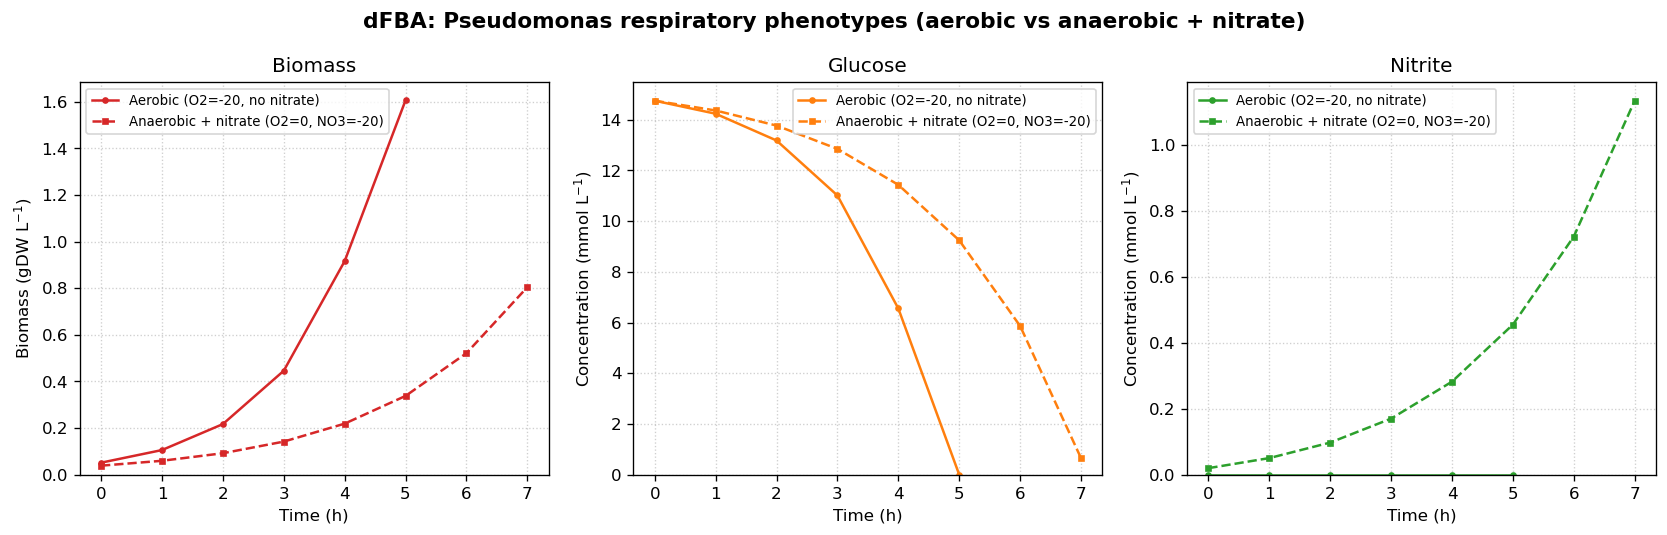

Saved figure: dfba_aerobic_vs_anaerobic_nitrate.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_dfba(model, o2_lb, nitrate_lb, glucose0=15.0, biomass0=0.025,
             t_end=8.0, dt=1):
    """Simple static-FBA dFBA on glucose (± O2, ± nitrate). Returns time-aligned trajectories."""
    # Fresh medium for this condition
    for rxn in model.exchanges:
        rxn.lower_bound = 0.0
        rxn.upper_bound = 1000.0

    inorganics = [
        "EX_cpd00001_e0", "EX_cpd00067_e0", "EX_cpd00009_e0", "EX_cpd00013_e0",
        "EX_cpd00048_e0", "EX_cpd00254_e0", "EX_cpd00063_e0", "EX_cpd00030_e0",
        "EX_cpd00034_e0", "EX_cpd10515_e0", "EX_cpd10516_e0", "EX_cpd00149_e0",
        "EX_cpd00058_e0", "EX_cpd00971_e0", "EX_cpd00205_e0",
        "EX_cpd00099_e0",  # Cl-
    ]
    for rid in inorganics:
        if rid in model.reactions:
            model.reactions.get_by_id(rid).lower_bound = -1000.0

    if "EX_cpd00027_e0" in model.reactions:
        model.reactions.EX_cpd00027_e0.lower_bound = -10.0  # max glucose uptake
    if "EX_cpd00007_e0" in model.reactions:
        model.reactions.EX_cpd00007_e0.lower_bound = o2_lb
        if o2_lb == 0.0:
            model.reactions.EX_cpd00007_e0.upper_bound = 0.0

    if "EX_cpd00209_e0" in model.reactions:
        model.reactions.EX_cpd00209_e0.lower_bound = nitrate_lb
    if "EX_cpd00075_e0" in model.reactions:
        # allow nitrite production / uptake freely for tracking
        model.reactions.EX_cpd00075_e0.lower_bound = -1000.0
        model.reactions.EX_cpd00075_e0.upper_bound = 1000.0

    if "rxn00062_c0" in model.reactions:
        model.reactions.rxn00062_c0.lower_bound = 0.92
    if "bio1_biomass" in model.reactions:
        model.objective = "bio1_biomass"

    if "DM_cpd00193_c0" in model.reactions:
        model.reactions.DM_cpd00193_c0.lower_bound = 0.0
        model.reactions.DM_cpd00193_c0.upper_bound = 0.0

    glucose, nitrite, biomass = glucose0, 0.0, biomass0
    times = np.arange(0, t_end, dt)
    glc_t, no2_t, bio_t, t_out = [], [], [], []

    for t in times:
        if glucose <= 1e-6 or biomass <= 0:
            break

        # Uptake cannot exceed available substrate / (biomass * dt)
        max_glc_uptake = glucose / (biomass * dt) if biomass * dt > 0 else 0.0
        if "EX_cpd00027_e0" in model.reactions:
            model.reactions.EX_cpd00027_e0.lower_bound = -min(10.0, max_glc_uptake)

        sol = model.optimize()
        if sol.status != "optimal" or sol.objective_value < 1e-9:
            break

        mu = sol.objective_value
        v_glc = sol.fluxes.get("EX_cpd00027_e0", 0.0)
        v_no2 = sol.fluxes.get("EX_cpd00075_e0", 0.0)  # >0 secretion, <0 uptake

        glucose = max(0.0, glucose + v_glc * biomass * dt)
        nitrite = max(0.0, nitrite + v_no2 * biomass * dt)
        biomass = max(0.0, biomass + mu * biomass * dt)

        t_out.append(t)
        glc_t.append(glucose)
        no2_t.append(nitrite)
        bio_t.append(biomass)

    return {
        "time": np.array(t_out),
        "Glucose": np.array(glc_t),
        "Nitrite": np.array(no2_t),
        "Biomass": np.array(bio_t),
    }


conditions = {
    "Aerobic (O2=-20, no nitrate)": dict(o2_lb=-20.0, nitrate_lb=0.0),
    "Anaerobic + nitrate (O2=0, NO3=-20)": dict(o2_lb=0.0, nitrate_lb=-20.0),
}

results = {}
print("=== V5: dFBA aerobic vs anaerobic + nitrate ===")
for label, kwargs in conditions.items():
    traj = run_dfba(model, **kwargs)
    results[label] = traj
    n = len(traj["time"])
    final_bio = traj["Biomass"][-1] if n else 0.0
    final_no2 = traj["Nitrite"][-1] if n else 0.0
    print(f"  {label}: {n} steps | final biomass={final_bio:.4f} | final nitrite={final_no2:.4f}")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=120, sharex=True)
styles = {
    "Aerobic (O2=-20, no nitrate)": dict(ls="-", marker="o", ms=3),
    "Anaerobic + nitrate (O2=0, NO3=-20)": dict(ls="--", marker="s", ms=3),
}
colors = {"Biomass": "#d62728", "Glucose": "#ff7f0e", "Nitrite": "#2ca02c"}

for ax, species in zip(axes, ["Biomass", "Glucose", "Nitrite"]):
    for label, traj in results.items():
        if len(traj["time"]) == 0:
            continue
        st = styles[label]
        ax.plot(traj["time"], traj[species], color=colors[species],
                linestyle=st["ls"], marker=st["marker"], markersize=st["ms"],
                label=label)
    ax.set_title(species)
    ax.set_xlabel("Time (h)")
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=8, loc="best")

ylabels = {
    "Biomass": r"Biomass (gDW L$^{-1}$)",
    "Glucose": r"Concentration (mmol L$^{-1}$)",
    "Nitrite": r"Concentration (mmol L$^{-1}$)",
}
for ax, species in zip(axes, ["Biomass", "Glucose", "Nitrite"]):
    ...
    ax.set_ylabel(ylabels[species])
fig.suptitle("dFBA: Pseudomonas respiratory phenotypes (aerobic vs anaerobic + nitrate)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("dfba_aerobic_vs_anaerobic_nitrate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure: dfba_aerobic_vs_anaerobic_nitrate.png")

# Restore aerobic medium
reset_minimal_glucose(model)



# Model application

## Acetate switch (simple dFBA)

Overflow on excess glucose, then reuptake when sugar is gone. Mild O₂ limit encourages secretion during growth; acetate exchange is bidirectional so consumption can appear afterward.


/home/gestrella/anaconda3/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Glucose ~0 at t ≈ 4.50 h | acetate peak at t ≈ 4.50 h (conc=0.199)
Flux after sugar gone: mean v_acetate = -2.4383  (<0 = uptake)


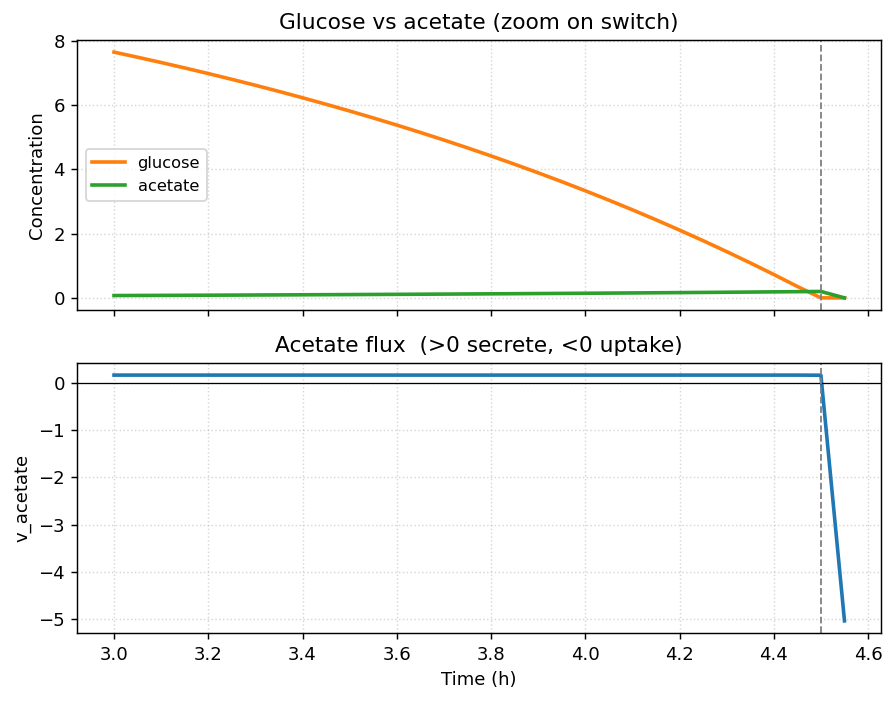

Saved: dfba_acetate_switch.png


['EX_cpd00007_e0',
 'EX_cpd00001_e0',
 'EX_cpd00067_e0',
 'EX_cpd00009_e0',
 'EX_cpd00013_e0',
 'EX_cpd00048_e0',
 'EX_cpd00254_e0',
 'EX_cpd00063_e0',
 'EX_cpd00030_e0',
 'EX_cpd00034_e0',
 'EX_cpd10515_e0',
 'EX_cpd10516_e0',
 'EX_cpd00149_e0',
 'EX_cpd00058_e0',
 'EX_cpd00971_e0',
 'EX_cpd00205_e0',
 'EX_cpd00099_e0',
 'EX_cpd00027_e0']

In [18]:
from cobra import Metabolite, Reaction
import numpy as np
import matplotlib.pyplot as plt

# --- acetate chemistry ---
if "cpd00029_c0" not in model.metabolites:
    model.add_metabolites([Metabolite("cpd00029_c0", name="Acetate", formula="C2H4O2", compartment="c0")])

for rid, eq in {
    "RXN_Acetic_acid": "cpd00022_c0 + cpd00001_c0 --> cpd00029_c0 + cpd00010_c0 + cpd00067_c0",
    "RXN_Acetate_uptake": "cpd00029_c0 + cpd00010_c0 + cpd00002_c0 --> cpd00022_c0 + cpd00008_c0 + cpd00009_c0",
}.items():
    if rid in model.reactions:
        model.reactions.get_by_id(rid).remove_from_model()
    rxn = Reaction(rid)
    model.add_reactions([rxn])
    try:
        rxn.reaction = eq
    except Exception:
        if rid == "RXN_Acetate_uptake":
            rxn.reaction = "cpd00029_c0 + cpd00010_c0 --> cpd00022_c0"

if "EX_cpd00029_e0" not in model.reactions:
    ex = Reaction("EX_cpd00029_e0")
    model.add_reactions([ex])
    ex.add_metabolites({model.metabolites.cpd00029_c0: -1})

# --- short dFBA (limited O2) ---
apply_minimal_medium(model, glucose_lb=-10, o2_lb=-8, verbose=False)
model.reactions.rxn00062_c0.bounds = (0.92, 0.92)

glc, x, ac = 12.0, 0.05, 0.0
dt = 0.05
T, GLC, AC, VAC, MU = [], [], [], [], []

for t in np.arange(0, 12, dt):
    model.reactions.EX_cpd00027_e0.lower_bound = 0 if glc < 1e-6 else -min(10, glc / max(x * dt, 1e-12))
    model.reactions.EX_cpd00029_e0.bounds = (
        0 if ac < 1e-6 else -min(20, ac / max(x * dt, 1e-12)),
        1000,
    )
    model.objective = "bio1_biomass"
    sol = model.optimize()
    if sol.status != "optimal":
        break

    mu = sol.fluxes.get("bio1_biomass", 0.0)
    v_g = sol.fluxes.get("EX_cpd00027_e0", 0.0)
    v_a = sol.fluxes.get("EX_cpd00029_e0", 0.0)

    glc = max(0, glc + v_g * x * dt)
    ac = max(0, ac + v_a * x * dt)
    x = max(0, x + mu * x * dt)

    T.append(t); GLC.append(glc); AC.append(ac); VAC.append(v_a); MU.append(mu)

T, GLC, AC, VAC, MU = map(np.array, (T, GLC, AC, VAC, MU))

t_glc0 = T[np.argmax(GLC < 1e-3)] if np.any(GLC < 1e-3) else T[-1]
t_peak = T[np.argmax(AC)]
print(f"Glucose ~0 at t ≈ {t_glc0:.2f} h | acetate peak at t ≈ {t_peak:.2f} h (conc={AC.max():.3f})")
print(f"Flux after sugar gone: mean v_acetate = {VAC[T >= t_glc0].mean():.4f}  (<0 = uptake)")

# zoom window around the switch
pad = 1.5
t0, t1 = max(0, t_glc0 - pad), min(T[-1], t_glc0 + pad)
mask = (T >= t0) & (T <= t1)

fig, ax = plt.subplots(2, 1, figsize=(7, 5.5), dpi=130, sharex=True)

ax[0].plot(T[mask], GLC[mask], color="#ff7f0e", lw=2, label="glucose")
ax[0].plot(T[mask], AC[mask], color="#2ca02c", lw=2, label="acetate")
ax[0].axvline(t_glc0, color="gray", ls="--", lw=1)
ax[0].set_ylabel("Concentration")
ax[0].set_title("Glucose vs acetate (zoom on switch)")
ax[0].legend(fontsize=9)
ax[0].grid(True, ls=":", alpha=0.5)

ax[1].plot(T[mask], VAC[mask], color="#1f77b4", lw=2)
ax[1].axhline(0, color="k", lw=0.7)
ax[1].axvline(t_glc0, color="gray", ls="--", lw=1)
ax[1].set_ylabel("v_acetate")
ax[1].set_xlabel("Time (h)")
ax[1].set_title("Acetate flux  (>0 secrete, <0 uptake)")
ax[1].grid(True, ls=":", alpha=0.5)

fig.tight_layout()
plt.savefig("dfba_acetate_switch.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dfba_acetate_switch.png")

apply_minimal_medium(model, verbose=False)


**Switch:** acetate rises while glucose is present; after the grey line (glucose ≈ 0), flux < 0 means reuptake and concentration falls.


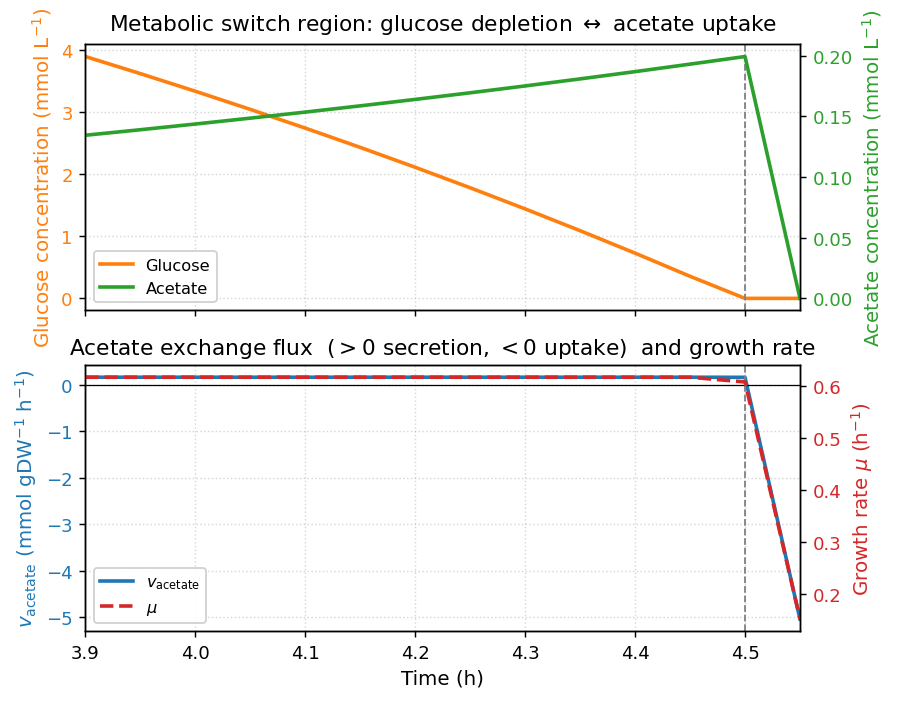

Saved: dfba_acetate_switch_zoom.png


In [23]:
# tighter zoom on the switch
pad_left, pad_right = 0.6, 0.9
t0, t1 = max(0, t_glc0 - pad_left), min(T[-1], t_glc0 + pad_right)
mask = (T >= t0) & (T <= t1)

fig, ax = plt.subplots(2, 1, figsize=(7, 5.5), dpi=130, sharex=True)

# ── top panel: glucose (left) + acetate (right) ──────────────────────────────
ax0 = ax[0]
ax0.plot(T[mask], GLC[mask], color="#ff7f0e", lw=2, label="Glucose")
ax0.set_ylabel(r"Glucose concentration (mmol L$^{-1}$)", color="#ff7f0e", fontsize=11)
ax0.tick_params(axis="y", labelcolor="#ff7f0e")
ax0.axvline(t_glc0, color="gray", ls="--", lw=1)
ax0.set_title(r"Metabolic switch region: glucose depletion $\leftrightarrow$ acetate uptake",
              fontsize=12, pad=8)
ax0.grid(True, ls=":", alpha=0.5)

ax0r = ax0.twinx()
ax0r.plot(T[mask], AC[mask], color="#2ca02c", lw=2, label="Acetate")
ax0r.set_ylabel(r"Acetate concentration (mmol L$^{-1}$)", color="#2ca02c", fontsize=11)
ax0r.tick_params(axis="y", labelcolor="#2ca02c")

# combined legend
h1, l1 = ax0.get_legend_handles_labels()
h2, l2 = ax0r.get_legend_handles_labels()
ax0.legend(h1 + h2, l1 + l2, fontsize=9, loc="best", framealpha=0.9)

# ── bottom panel: acetate exchange flux (left) + growth rate (right) ─────────
ax1 = ax[1]
ax1.plot(T[mask], VAC[mask], color="#1f77b4", lw=2, label=r"$v_{\rm acetate}$")
ax1.axhline(0, color="k", lw=0.7)
ax1.axvline(t_glc0, color="gray", ls="--", lw=1)
ax1.set_ylabel(r"$v_{\rm acetate}$ (mmol gDW$^{-1}$ h$^{-1}$)",
               color="#1f77b4", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_xlabel(r"Time (h)", fontsize=11)
ax1.set_title(r"Acetate exchange flux  ($>0$ secretion, $<0$ uptake)  and growth rate",
              fontsize=12, pad=6)
ax1.grid(True, ls=":", alpha=0.5)
ax1.set_xlim(t0, t1)

ax1r = ax1.twinx()
ax1r.plot(T[mask], MU[mask], color="#d62728", lw=2, ls="--", label=r"$\mu$")
ax1r.set_ylabel(r"Growth rate $\mu$ (h$^{-1}$)", color="#d62728", fontsize=11)
ax1r.tick_params(axis="y", labelcolor="#d62728")

# combined legend for bottom panel
h3, l3 = ax1.get_legend_handles_labels()
h4, l4 = ax1r.get_legend_handles_labels()
ax1.legend(h3 + h4, l3 + l4, fontsize=9, loc="best", framealpha=0.9)

fig.tight_layout()
plt.savefig("dfba_acetate_switch.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dfba_acetate_switch_zoom.png")